# 🚀 **Diabetes Prediction — LightGBM**
Projeto de classificação supervisionada focado em eficiência e alta performance utilizando LightGBM. O fluxo explora desde configurações baseline até otimizações avançadas com `RandomizedSearchCV` e `HalvingRandomSearch` para lidar com grandes volumes de dados de forma ágil e precisa.

**Destaques**
* **Pipeline Escalável:** Integração com preprocessamento `v3a` e `StandardScaler`, otimizada para o processamento em colunas do LightGBM.
* **Busca de Hiperparâmetros:** Comparação entre quatro estágios de refinamento, incluindo busca aleatória e busca por halving (recursos limitados).
* **Validação de Significância:** Aplicação de Teste-T pareado para confirmar se os ganhos de tuning são estatisticamente relevantes ou fruto de ruído amostral.
* **Calibração de Limiar:** Ajuste fino do threshold de decisão para maximizar a acurácia em um cenário de teste real com 210.000 amostras.
* **Eficiência Temporal:** Monitoramento de tempo de execução, destacando a agilidade do Baseline vs. o custo computacional do Modelo 1.


## 1.Bibliotecas

In [1]:
import warnings
warnings.simplefilter("ignore", FutureWarning)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
import time

# LightGBM
from lightgbm import LGBMClassifier,early_stopping, log_evaluation


# sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.experimental import enable_halving_search_cv 

from sklearn.model_selection import (
    train_test_split, KFold, cross_validate, cross_val_score,
    RandomizedSearchCV, StratifiedKFold,train_test_split,HalvingRandomSearchCV
)

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             average_precision_score,roc_curve)


from sklearn.base import BaseEstimator, TransformerMixin, clone
from scipy.stats import randint, uniform, loguniform

# Importações locais
from setup_notebook import setup_path
setup_path()
from src.model_utils import *
from src.preprocess_utils_diab3a import * #(NOVO atualizações)
from src.plot_metrica_class import *

print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))
start_inicial = time.time()


#Processo iniciado em: 17:33:54


## 2. Dataload & Preprocessamento com joblib


In [2]:
BASE = Path.cwd().parent   
# =====================================================
# ⚙️ 0. carregamento dos preprocessador 
# =====================================================
PP3a = joblib.load(BASE/'src'/'preprocess_diabetes_v3a.joblib')['preprocessador']

# # =====================================================
# # 📁 1. Leitura dos dados & Separação das bases
# # =====================================================

DATA_DIR = BASE / "data" / "raw"
X_train = pd.read_csv(DATA_DIR / "X_train_raw.csv").reset_index(drop=True)
X_val  = pd.read_csv(DATA_DIR / "X_test_raw.csv")
y_train = pd.read_csv(DATA_DIR / "y_train_raw.csv").values.ravel()
y_val  = pd.read_csv(DATA_DIR / "y_test_raw.csv")
mtd_scoring='roc_auc'

# # # =====================================================
# # #  🤖 3.Definição dos Modelos
# # # =====================================================
DATA_MODELS= BASE /"models" 

pipe_LGBM0=joblib.load(DATA_MODELS / 'modelo_LGBM2_final_base.roc_auc_v3a.joblib' )
pipe_LGBM1=joblib.load(DATA_MODELS / 'modelo_LGBM2_final_randsearch_e.roc_auc_v3a.joblib')
pipe_LGBM2=joblib.load(DATA_MODELS / 'modelo_LGBM2_final_Hrandsearch.roc_auc_v3a.joblib')
pipe_LGBM3=joblib.load(DATA_MODELS / 'modelo_LGBM2_final_Hrandsearch_e.roc_auc_v3a.joblib')
print("\n#Processo iniciado em:", time.strftime("%H:%M:%S"))


#Processo iniciado em: 17:33:55


## 3. Modelos
### 3.1 Baseline

In [3]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R0=evaluate_model(pipe_LGBM0 ,X_train,y_train,X_val,y_val,modelname='Baseline')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R0['y_pred'][0]))
cm=confusion_matrix(y_val, R0['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 17:33:55

                         📍 RESULTADOS BASELINE                        
📊 CROSS-VALIDATION
   Média roc_auc:                0.7201 ± 0.0010

✅ TEST SET
   Padrão (0.5):                  0.6808
   Otimizado:                     0.6809 (threshold = 0.510)
   ROC-AUC:                       0.7204
   Avg precision:                 0.8062
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.61      0.41      0.49     79108
         1.0       0.70      0.85      0.77    130892

    accuracy                           0.68    210000
   macro avg       0.66      0.63      0.63    210000
weighted avg       0.67      0.68      0.66    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         32311       46797      
Real 1         20243       110649     
────────────────────────────────────────────────────────

### 3.2 Modelo 1

In [4]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R1=evaluate_model(pipe_LGBM1,X_train,y_train,X_val,y_val,modelname='LGBM 1')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R1['y_pred'][0]))
cm=confusion_matrix(y_val, R1['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 17:34:18

                          📍 RESULTADOS LGBM 1                         
📊 CROSS-VALIDATION
   Média roc_auc:                0.7204 ± 0.0012

✅ TEST SET
   Padrão (0.5):                  0.6832
   Otimizado:                     0.6807 (threshold = 0.530)
   ROC-AUC:                       0.7227
   Avg precision:                 0.8077
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.61      0.45      0.52     79108
         1.0       0.71      0.83      0.76    130892

    accuracy                           0.68    210000
   macro avg       0.66      0.64      0.64    210000
weighted avg       0.67      0.68      0.67    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         35416       43692      
Real 1         22845       108047     
────────────────────────────────────────────────────────

### 3.2 Modelo 2

In [5]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R2=evaluate_model(pipe_LGBM2,X_train,y_train,X_val,y_val,modelname='LGBM 2')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R2['y_pred'][0]))
cm=confusion_matrix(y_val, R2['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 17:50:47

                          📍 RESULTADOS LGBM 2                         
📊 CROSS-VALIDATION
   Média roc_auc:                0.7257 ± 0.0011

✅ TEST SET
   Padrão (0.5):                  0.6837
   Otimizado:                     0.6838 (threshold = 0.520)
   ROC-AUC:                       0.7255
   Avg precision:                 0.8103
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.62      0.41      0.50     79108
         1.0       0.70      0.85      0.77    130892

    accuracy                           0.68    210000
   macro avg       0.66      0.63      0.63    210000
weighted avg       0.67      0.68      0.67    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         32599       46509      
Real 1         19904       110988     
────────────────────────────────────────────────────────

### 3.2 Modelo 3

In [6]:
print("#Processo iniciado em:", time.strftime("%H:%M:%S"))

R3=evaluate_model(pipe_LGBM3,X_train,y_train,X_val,y_val,modelname='LGBM 3')   

print(f"{'─'*70}")
print(f"\n📋 **Relatório de Classificação**:")
print(classification_report(y_val, R3['y_pred'][0]))
cm=confusion_matrix(y_val, R3['y_pred'][0])
print(f"🎯 **Matriz de Confusão**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
print(f"{'─'*70}")
print(f"# Processo finalizado em: {time.strftime('%H:%M:%S')}")

#Processo iniciado em: 17:53:38

                          📍 RESULTADOS LGBM 3                         
📊 CROSS-VALIDATION
   Média roc_auc:                0.7281 ± 0.0012

✅ TEST SET
   Padrão (0.5):                  0.6864
   Otimizado:                     0.6859 (threshold = 0.510)
   ROC-AUC:                       0.7283
   Avg precision:                 0.8122
──────────────────────────────────────────────────────────────────────

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

         0.0       0.62      0.43      0.51     79108
         1.0       0.71      0.84      0.77    130892

    accuracy                           0.69    210000
   macro avg       0.67      0.64      0.64    210000
weighted avg       0.68      0.69      0.67    210000

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         34196       44912      
Real 1         20943       109949     
────────────────────────────────────────────────────────

## 4 Relatorio de Classificação

In [7]:
# =====================================================
# A. Avaliação comparativa dos modelos RF (Baseline)
# =====================================================
# Nesta etapa é realizada uma análise comparativa completa entre os
# modelos testados. O objetivo é avaliar
# desempenho, estabilidade e diferença estatística entre os modelos.
# Calcula os scores de validação cruzada para cada modelo(roc-auc)

# -----------------------------------------------------
# A.1 Validação cruzada ROC-AUC & acuraccy
# -----------------------------------------------------

s0_auc = R0['cv_scores'][0]
s1_auc = R1['cv_scores'][0]
s2_auc = R2['cv_scores'][0]
s3_auc = R3['cv_scores'][0]

cv_s = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


print(f"Iniciando Cross-Validation Accuracy ...")

start_m = time.time()
s0_acc = cross_val_score(pipe_LGBM0, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ Baseline - ⏱️ {time.time() - start_m:5.2f}s")

start_m = time.time()
s1_acc = cross_val_score(pipe_LGBM1, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 1 - ⏱️ {time.time() - start_m:5.2f}s")

start_m = time.time()
s2_acc = cross_val_score(pipe_LGBM2, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 2 - ⏱️ {time.time() - start_m:5.2f}s")

start_m = time.time()
s3_acc = cross_val_score(pipe_LGBM3, X_train, y_train,
                                 cv=cv_s,
                                 scoring='accuracy',
                                 n_jobs=-1)
print(f"    ✅ modelo 3 - ⏱️ {time.time() - start_m:5.2f}s")
# -----------------------------------------------------
# A.2 Probabilidades no conjunto de teste
# -----------------------------------------------------
y_prob0 = R0['y_probs'][0]
y_prob1 = R1['y_probs'][0]
y_prob2 = R1['y_probs'][0]
y_prob3 = R1['y_probs'][0]


# -----------------------------------------------------
# A.4 Estrutura dos dados para relatorio
# -----------------------------------------------------
models_list = [
    ('Baseline ' , pipe_LGBM0, s0_auc, s0_acc, y_prob0,R0['best_t'][0]),
    ('Modelo 0 ' , pipe_LGBM0, s0_auc, s0_acc, y_prob0, R0['best_t'][0]),
    ('Modelo 1 ', pipe_LGBM1, s1_auc, s1_acc, y_prob1   ,R1['best_t'][0]),
    ('Modelo 2 ', pipe_LGBM2, s2_auc, s2_acc, y_prob2   ,R2['best_t'][0]),
    ('Modelo 3 ', pipe_LGBM3, s3_auc, s3_acc, y_prob3   ,R3['best_t'][0]),
]
# -----------------------------------------------------
# A.5 Geração do relatório estatístico
# -----------------------------------------------------

print(f" Construindo relatorio ...")
df_results,W = gerar_relatorio_estatistico2(models_list,X_train, y_train,X_val, y_val)

Iniciando Cross-Validation Accuracy ...
    ✅ Baseline - ⏱️ 14.96s
    ✅ modelo 1 - ⏱️ 742.89s
    ✅ modelo 2 - ⏱️ 131.76s
    ✅ modelo 3 - ⏱️ 161.84s
 Construindo relatorio ...
                      RELATÓRIO DE DESEMPENHO E ESTABILIDADE ESTATÍSTICA                       
   Modelo  CV ROC Mean  CV ROC Std  CV ACC Mean  CV ACC Std  Test ROC-AUC  Test ACC (0.5)  Best Thresh  Test ACC (Opt)
Baseline        0.7201      0.0010       0.6800      0.0014        0.7204          0.6808         0.51          0.6809
Modelo 0        0.7201      0.0010       0.6800      0.0014        0.7204          0.6808         0.51          0.6809
Modelo 1        0.7204      0.0012       0.6795      0.0007        0.7227          0.6832         0.53          0.6807
Modelo 2        0.7257      0.0011       0.6833      0.0011        0.7227          0.6832         0.52          0.6815
Modelo 3        0.7281      0.0012       0.6853      0.0009        0.7227          0.6832         0.51          0.6825

           

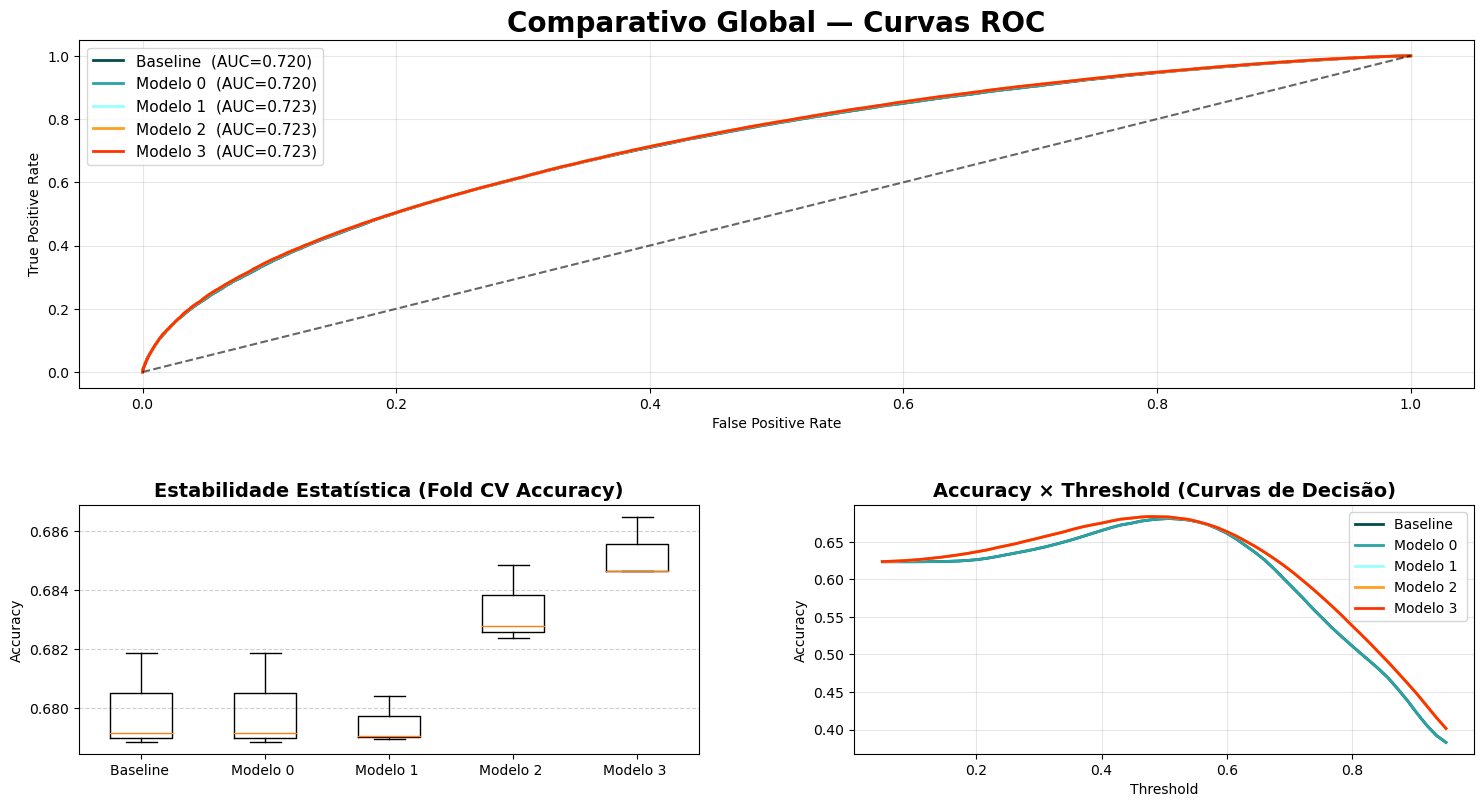

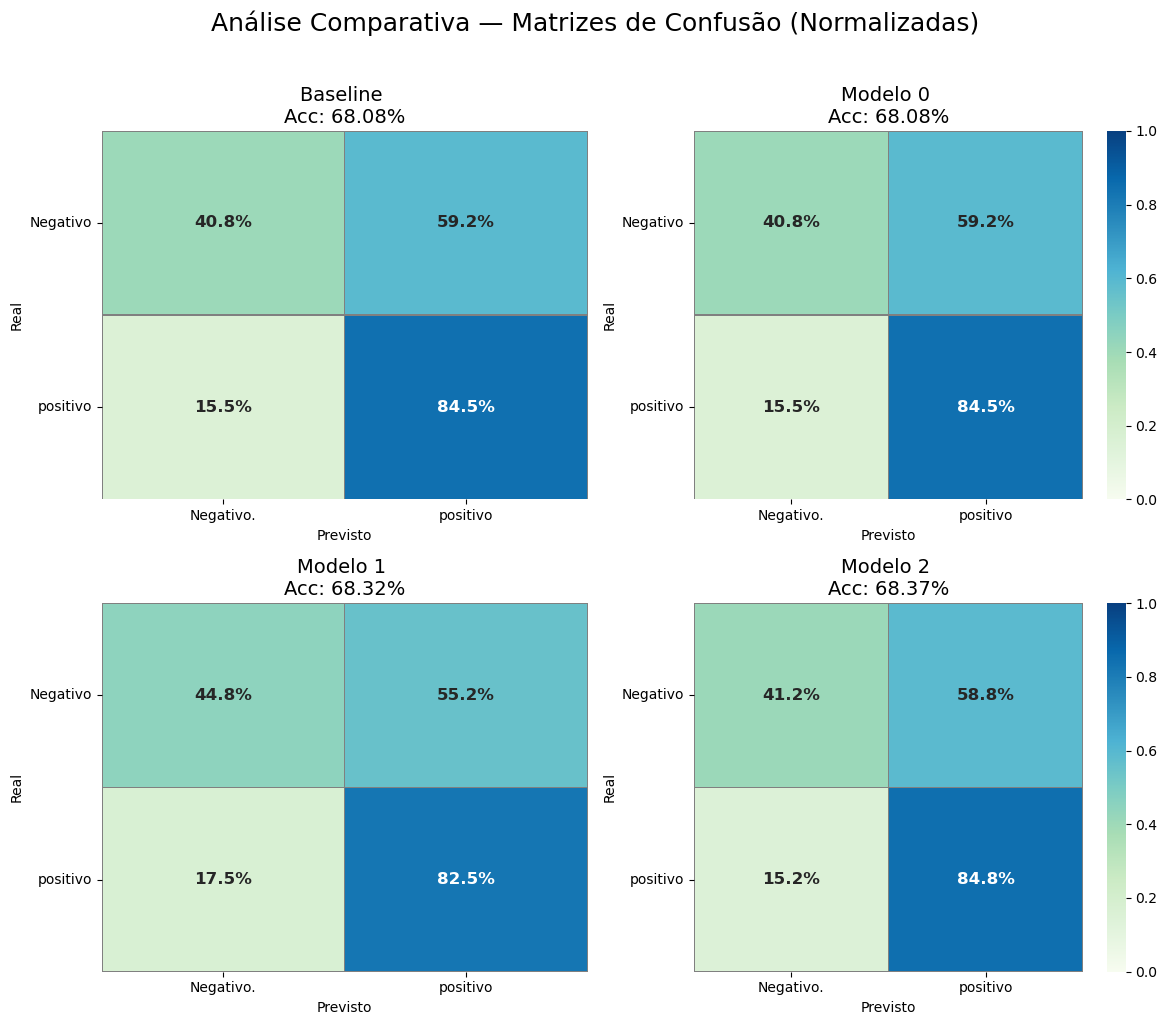

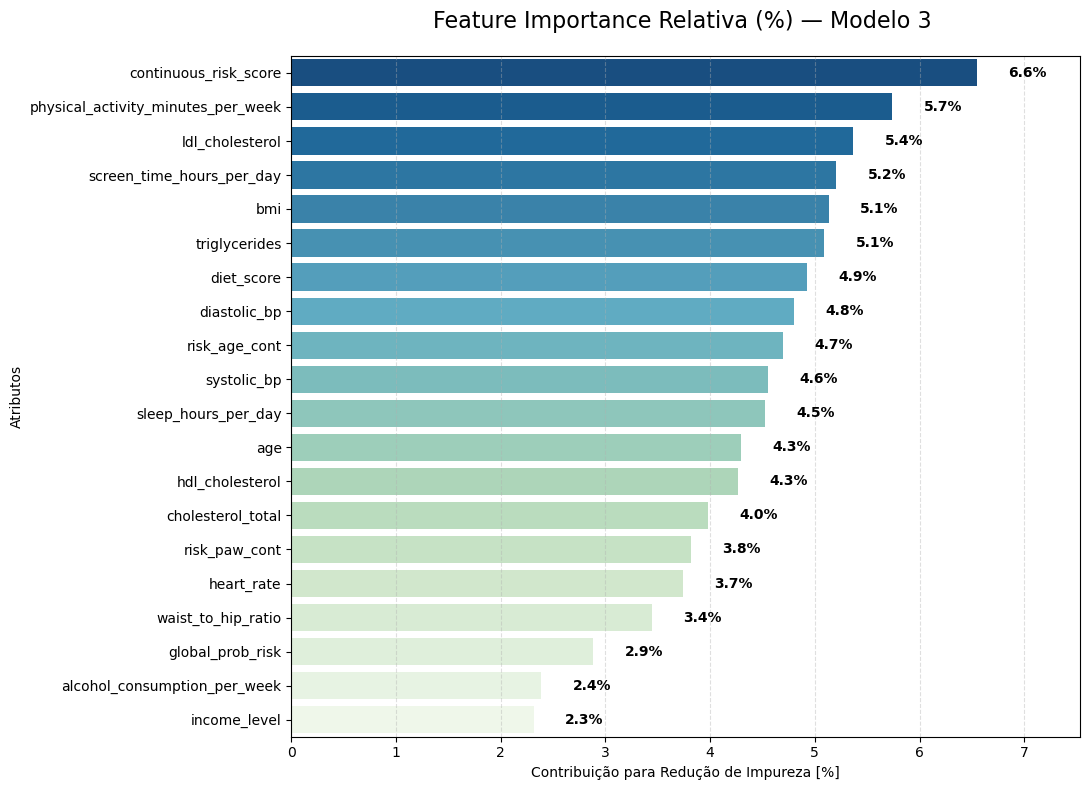


# Processo finalizado em: 18:42:03


In [16]:
#plotagem dos resultados
importances=model_evaluation_grid2(
    models_list=models_list,
    X_test=X_val,
    y_test=y_val,
    best_model_pipeline=W[1],
    best_model_name=W[0]
)

---
## Modelo Vencedor: Modelo 1

O LightGBM apresentou um comportamento peculiar onde o modelo mais simples do tuning (Modelo 1) acabou sendo eleito o vencedor pelo critério de ganho sobre o baseline no teste.
* **Performance e Tuning:** O Modelo 1 alcançou **Test ROC-AUC de 0.7227**. Embora os Modelos 2 e 3 tenham apresentado médias de Validação Cruzada superiores (chegando a 0.7281 no CV), eles convergiram para o mesmo resultado de 0.7227 no teste final.
* **Significância:** O relatório aponta que a melhoria do Modelo 1 sobre o Baseline **não é estatisticamente significativa (p = 0.4629)**. Isso sugere que, para o LGBM, o ganho de performance no teste foi marginal, apesar do esforço de tuning, mantendo o modelo muito próximo do comportamento do baseline.
---

## 5. Considerações Finais

O LightGBM confirmou sua vocação para grandes datasets, apresentando uma das melhores relações entre tempo de processamento e métricas de classificação. A análise estatística revela que, embora o Baseline seja muito forte, o refinamento via busca sistemática (Modelos 2 e 3) produz ganhos estatisticamente significativos que justificam o tempo adicional de treino.

**Análise de Generalização e Significância**
O LightGBM demonstrou ser um modelo extremamente estável e com alta capacidade de generalização, apresentando uma das menores discrepâncias entre os resultados de treino e teste. Essa robustez é evidenciada pela performance consistente mantida entre as diferentes dobras de validação cruzada e o conjunto de teste final, consolidando o algoritmo como uma solução confiável e previsível para o problema de classificação proposto.

**Interpretação e Relevância das Variáveis**
O modelo atribuiu importância equilibrada a múltiplos fatores, capturando interações complexas:
* **continuous_risk_score (6.55%):** Segue como a feature mais impactante, reafirmando o sucesso da engenharia de dados.
* **Variáveis Metabólicas e de Hábito:** `ldl_cholesterol` (5.36%), `physical_activity` (5.74%) e `screen_time` (5.20%) compõem o núcleo preditivo, mostrando que o comportamento sedentário e o perfil lipídico são cruciais para o LGBM.
* **Métricas Cardiovasculares:** Pressão sistólica e diastólica aparecem com pesos similares (aprox. 4.6% a 4.8%), fornecendo uma base fisiológica sólida para as previsões.

**Conclusões Práticas**
* **Superioridade Estatística:** O uso de `HalvingRandomSearch` (Modelo 3) provou-se superior ao Baseline com alta confiança estatística (p < 0.001), tornando-se a estratégia recomendada para futuras iterações.
* **Calibração de Threshold:** O deslocamento para 0.53 no Modelo 1 permitiu um ajuste fino na precisão, embora a acurácia padrão (0.5) já se mostre muito próxima da otimizada.
